[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElenaVillano/prope-programacion/blob/main/materiales/m08_visualizacion.ipynb)

# Propedéutico de Programación para el Análisis de datos

## EGobiernoyTP

**Verano 2026**

# Análisis exploratorio y visualización de datos

En este notebook trabajaremos con la misma base para construir cuatro visualizaciones:

1. Histograma de `value`
2. Boxplot de `value`
3. Gráfico de barras
4. Línea del tiempo

Usaremos `pandas` y `matplotlib`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Cargar y preparar los datos

Modifica la ruta si el archivo se encuentra en otra carpeta.

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/ElenaVillano/prope-programacion/refs/heads/main/data/datos.csv')
df.head()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Quartile Range,Suppression Flag
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,15,"Sep 16 - Sep 28, 2020",09/16/2020,09/28/2020,6.9,6.5,7.3,6.5 - 7.3,NaN,NaN
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,15,"Sep 16 - Sep 28, 2020",09/16/2020,09/28/2020,11.0,10.4,11.6,10.4 - 11.6,NaN,NaN
2,Needed Counseling or Therapy But Did Not Get I...,By Sex,United States,Female,-1,1,"Dec 22, 2020 - Jan 5, 2021",12/22/2020,01/05/2021,NaN,NaN,NaN,NaN,NaN,NaN
3,Took Prescription Medication for Mental Health...,By Age,United States,50 - 59 years,-1,1,"Mar 30 - Apr 13, 2021",03/30/2021,04/13/2021,NaN,NaN,NaN,NaN,NaN,NaN
4,Took Prescription Medication for Mental Health...,By Age,United States,60 - 69 years,-1,1,"Mar 30 - Apr 13, 2021",03/30/2021,04/13/2021,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['indicator', 'group', 'state', 'subgroup', 'phase', 'time_period',
       'time_period_label', 'time_period_start_date', 'time_period_end_date',
       'value', 'lowci', 'highci', 'confidence_interval', 'quartile_range',
       'suppression_flag'],
      dtype='str')

In [5]:
df["value"].describe()

count    9914.000000
mean       17.450736
std         8.270565
min         1.400000
25%        10.300000
50%        16.200000
75%        24.000000
max        62.900000
Name: value, dtype: float64

# 2. Histograma

Un **histograma** permite observar la distribución de una variable numérica.

**Pregunta:** ¿Cómo se distribuyen los valores de `value`?

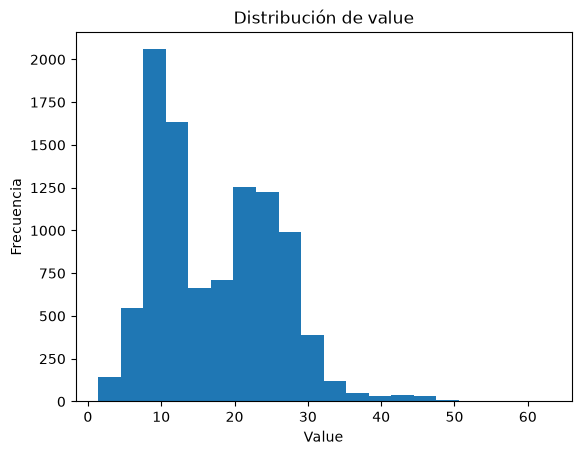

In [6]:
plt.hist(df["value"].dropna(), bins=20)

plt.xlabel("Value")
plt.ylabel("Frecuencia")
plt.title("Distribución de value")

plt.show()

Podemos modificar `bins` para cambiar el número de intervalos.

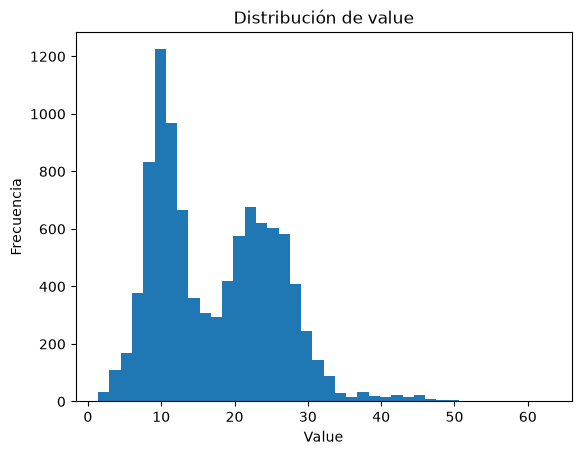

In [7]:
plt.hist(df["value"].dropna(), bins=40)

plt.xlabel("Value")
plt.ylabel("Frecuencia")
plt.title("Distribución de value")

plt.show()

# 3. Boxplot

Un **boxplot** resume la distribución y permite observar la mediana, los cuartiles, la dispersión y posibles valores atípicos.

/var/folders/dz/thvmrq455js1_2td0ql2bdb40000gn/T/ipykernel_57490/230186099.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["value"].dropna(), vert=False)


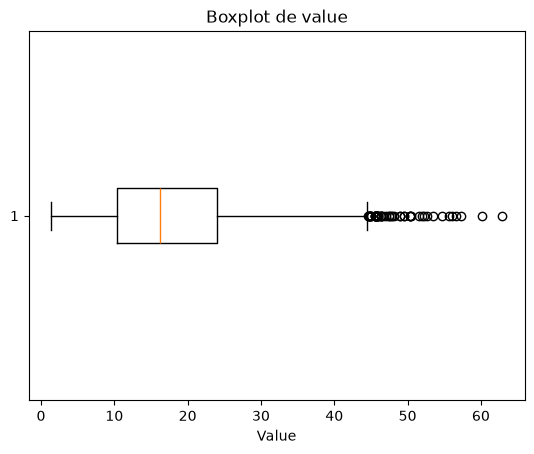

In [8]:
plt.boxplot(df["value"].dropna(), vert=False)

plt.xlabel("Value")
plt.title("Boxplot de value")

plt.show()

# 4. Gráfico de barras

Los gráficos de barras permiten comparar cantidades entre categorías.

Primero contamos cuántas observaciones existen para cada `group`.

In [9]:
conteo_grupo = df["group"].value_counts()
conteo_grupo

group
By State                                         6732
By Age                                           1064
By Race/Hispanic ethnicity                        760
By Education                                      608
By Sex                                            304
By Presence of Symptoms of Anxiety/Depression     304
By Disability status                              168
By Sexual orientation                             156
By Gender identity                                156
National Estimate                                 152
Name: count, dtype: int64

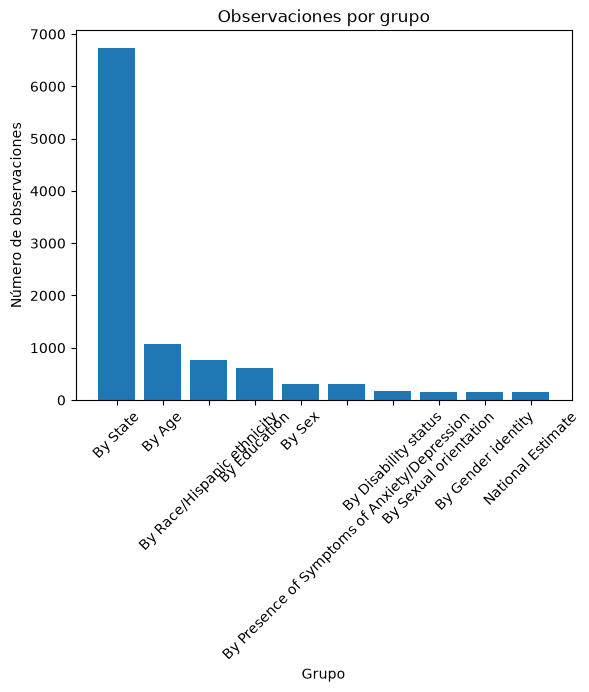

In [10]:
plt.bar(conteo_grupo.index, conteo_grupo.values)

plt.xlabel("Grupo")
plt.ylabel("Número de observaciones")
plt.title("Observaciones por grupo")
plt.xticks(rotation=45)

plt.show()

También podemos combinar `groupby()` con una gráfica de barras. Por ejemplo, calculamos el promedio de `value` por grupo.

In [11]:
promedio_grupo = (
    df
    .groupby("group")
    .agg(promedio=("value", "mean"))
    .reset_index()
)

promedio_grupo

,group,promedio
0,By Age,15.960263
1,By Disability status,23.915972
2,By Education,16.395644
3,By Gender identity,25.962500
4,By Presence of Symptoms of Anxiety/Depression,19.979545
5,By Race/Hispanic ethnicity,15.207879
6,By Sex,16.648106
7,By Sexual orientation,26.588889
8,By State,17.384040
9,National Estimate,16.809091


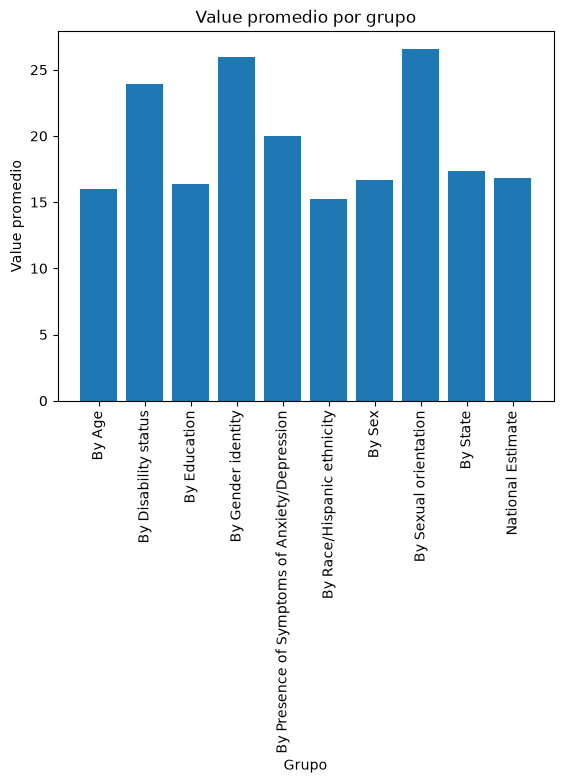

In [17]:
plt.bar(promedio_grupo["group"], promedio_grupo["promedio"])

plt.xlabel("Grupo")
plt.ylabel("Value promedio")
plt.title("Value promedio por grupo")
plt.xticks(rotation=90)

plt.show()

# 5. Línea del tiempo

Para construir una línea del tiempo necesitamos que la fecha tenga un tipo de dato adecuado.

In [18]:
df["time_period_start_date"] = pd.to_datetime(
    df["time_period_start_date"]
)

df["time_period_start_date"].dtype

dtype('<M8[us]')

Como existen múltiples observaciones para una misma fecha, primero resumimos la información calculando el promedio de `value` por fecha.

In [19]:
serie_tiempo = (
    df
    .groupby("time_period_start_date")
    .agg(promedio_value=("value", "mean"))
    .reset_index()
    .sort_values("time_period_start_date")
)

serie_tiempo.head()

,time_period_start_date,promedio_value
0,2020-08-19,15.060417
1,2020-09-02,15.486806
2,2020-09-16,15.640418
3,2020-09-30,15.394792
4,2020-10-14,16.187456


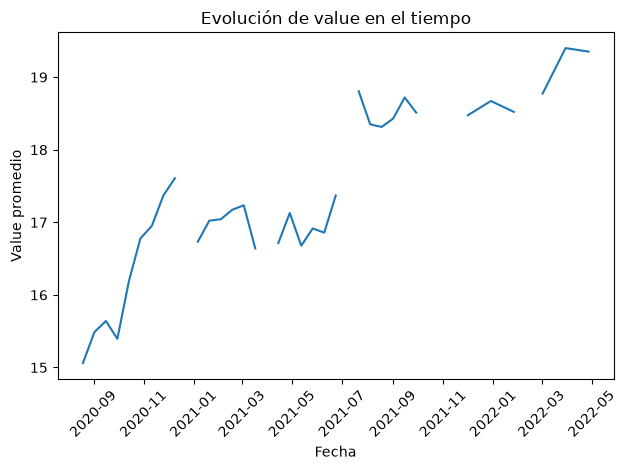

In [20]:
plt.plot(
    serie_tiempo["time_period_start_date"],
    serie_tiempo["promedio_value"]
)

plt.xlabel("Fecha")
plt.ylabel("Value promedio")
plt.title("Evolución de value en el tiempo")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Línea del tiempo para un indicador

Una gráfica agregada puede mezclar fenómenos diferentes. Podemos seleccionar un indicador antes de construir la línea del tiempo.

Primero observamos algunos indicadores disponibles.

In [21]:
df["indicator"].value_counts().head()

indicator
Received Counseling or Therapy, Last 4 Weeks                                                          2601
Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks                                         2601
Took Prescription Medication for Mental Health, Last 4 Weeks                                          2601
Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks    2601
Name: count, dtype: int64

In [22]:
indicador = df["indicator"].dropna().unique()[0]
indicador

'Received Counseling or Therapy, Last 4 Weeks'

In [23]:
df_indicador = df[df["indicator"] == indicador]

serie_indicador = (
    df_indicador
    .groupby("time_period_start_date")
    .agg(promedio_value=("value", "mean"))
    .reset_index()
    .sort_values("time_period_start_date")
)

serie_indicador.head()

,time_period_start_date,promedio_value
0,2020-08-19,8.706944
1,2020-09-02,8.937500
2,2020-09-16,8.831944
3,2020-09-30,8.894444
4,2020-10-14,9.812676


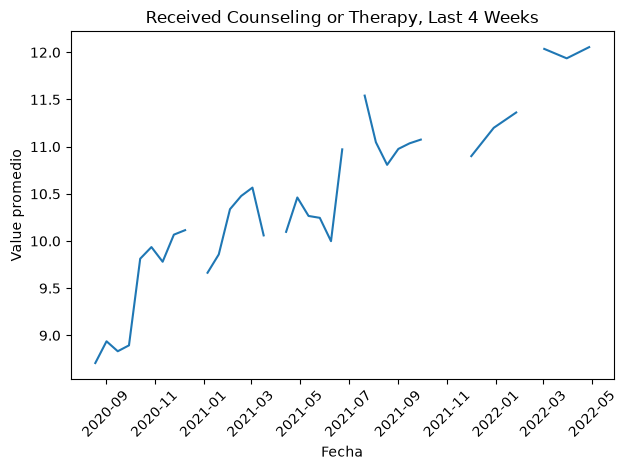

In [24]:
plt.plot(
    serie_indicador["time_period_start_date"],
    serie_indicador["promedio_value"]
)

plt.xlabel("Fecha")
plt.ylabel("Value promedio")
plt.title(indicador)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 6. Preguntas para explorar

A partir de estas visualizaciones podemos plantear preguntas como:

- ¿La distribución de `value` es simétrica?
- ¿Existen valores atípicos?
- ¿Qué grupos tienen más observaciones?
- ¿Hay diferencias en `value` entre grupos?
- ¿Cómo cambia `value` a lo largo del tiempo?
- ¿La tendencia temporal cambia dependiendo del indicador, estado o subgrupo?

La visualización sirve para **explorar los datos y generar nuevas preguntas**, además de comunicar resultados.